# HMC + DPF-OT vs PMMH for Nonlinear SSM Parameter Inference

## Overview

This notebook investigates whether entropy-regularised **Optimal Transport (OT) resampling** can replace the discrete multinomial step in a particle filter, and whether the resulting differentiable filter (DPF-OT) can serve as a drop-in likelihood for **Hamiltonian Monte Carlo (HMC)** parameter inference.

**Model (standard SMC benchmark — Gordon, Salmond & Smith 1993):**

$$X_1 \sim \mathcal{N}(0,5),\quad X_n = \frac{X_{n-1}}{2} + \frac{25X_{n-1}}{1+X_{n-1}^2} + 8\cos(1.2n) + V_n,\quad Y_n = \frac{X_n^2}{20} + W_n$$

$V_n \sim \mathcal{N}(0,\sigma_v^2)$, $W_n \sim \mathcal{N}(0,\sigma_w^2)$, $T=50$. **Goal:** infer $(\sigma_v, \sigma_w)$ from $Y_{1:T}$.

---

## Key Ideas

**Why standard PF breaks HMC.** A bootstrap particle filter resamples by drawing discrete indices from the weight distribution. This index-selection operation has zero gradient almost everywhere — `tf.GradientTape` returns `None` — so gradient-based samplers like HMC cannot be used directly.

**The OT fix.** Sinkhorn's algorithm solves an entropy-regularised optimal transport problem between the current empirical measure and a uniform target. The solution is expressed as a *barycentric projection* — a weighted average of source particles — which is fully differentiable. Replacing multinomial resampling with this step restores the gradient path.

**Pseudo-marginal HMC with CRN.** Because the OT log-likelihood is stochastic (different particle noise → different value), we use *common random numbers* (CRN): the same noise draw is held fixed for the entire leapfrog trajectory and reused in the Metropolis–Hastings acceptance step. This makes the noise cancel in the ratio, preserving detailed balance while dramatically reducing MC variance.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.join('..', 'simulator'))
sys.path.insert(0, os.path.join('..', 'models'))

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time

from simulator_nonlinSSM import simulate_nonlinear_ssm
from DPF_OT_resampling import DPF_OT, sinkhorn_ot_resample
from HMC_inference import HMCSampler, HMCConfig, compute_ess, compute_ess_per_second
from PMMH_inference import PMMHSampler, PMMHConfig

print(f"TF version : {tf.__version__}")
print("✓ All imports successful")

TF version : 2.20.0
✓ All imports successful


Simulated T=50 steps  |  σ_v=1.0, σ_w=1.0
State range      : [-16.18, 15.63]
Observation range: [-1.41, 13.45]


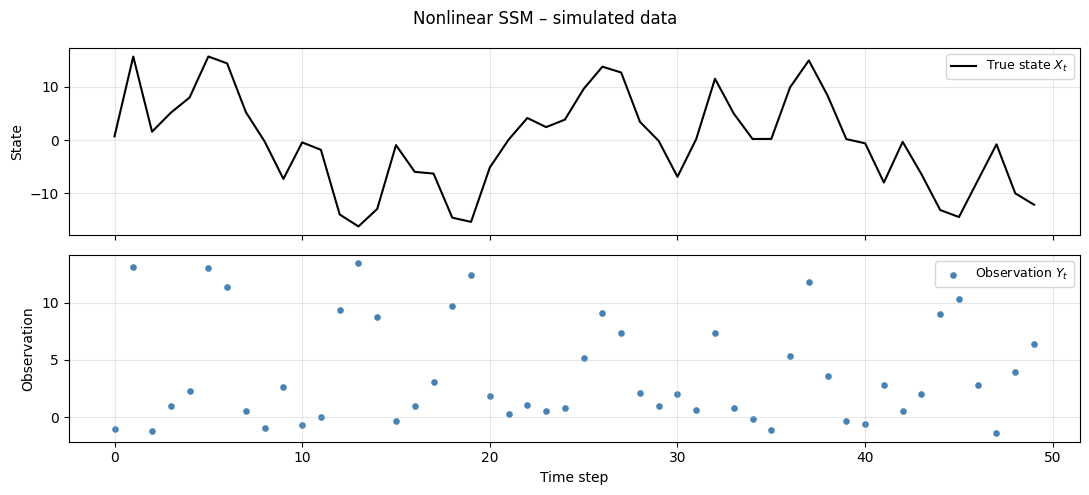

In [2]:
# ── Simulate data ─────────────────────────────────────────────────────────────
sigma_v_true = 1.0
sigma_w_true = 1.0
T = 50
SEED = 42

sim = simulate_nonlinear_ssm(N=T, sigma_v=sigma_v_true, sigma_w=sigma_w_true, seed=SEED)
observations = sim.Y          # shape (T,)
states       = sim.X          # shape (T,)  – true latent states

print(f"Simulated T={T} steps  |  σ_v={sigma_v_true}, σ_w={sigma_w_true}")
print(f"State range      : [{states.min():.2f}, {states.max():.2f}]")
print(f"Observation range: [{observations.min():.2f}, {observations.max():.2f}]")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax1.plot(states, 'k-', linewidth=1.5, label='True state $X_t$')
ax1.set_ylabel('State')
ax1.legend(fontsize=9);  ax1.grid(alpha=0.3)
ax2.scatter(range(T), observations, s=14, c='steelblue', label='Observation $Y_t$')
ax2.set_xlabel('Time step');  ax2.set_ylabel('Observation')
ax2.legend(fontsize=9);  ax2.grid(alpha=0.3)
plt.suptitle('Nonlinear SSM – simulated data', fontsize=12)
plt.tight_layout()
plt.show()

## Gradient Flow Through OT Resampling

- Compute $\partial \mathcal{L}/\partial \sigma_v$ and $\partial \mathcal{L}/\partial \sigma_w$ after an OT resample step. Both should be non-zero finite tensors.
- Repeat with multinomial resampling. Both gradients should be `None`, confirming that the standard PF breaks backpropagation.


In [ ]:


from DPF_OT_resampling import sinkhorn_ot_resample

# Ground truth observation at t=0 (already computed above)
y0 = tf.constant(float(observations[0]), dtype=tf.float32)

# gradient through OT resampling 
params_e1 = tf.Variable([1.0, 1.0], dtype=tf.float32, name="sigma_v_w")

with tf.GradientTape() as tape_ot:
    sigma_v_e1 = tf.abs(params_e1[0]) + 1e-3
    sigma_w_e1 = tf.abs(params_e1[1]) + 1e-3

    N_e1 = 200
    tf.random.set_seed(0)
    particles_e1 = tf.random.normal([N_e1, 1], mean=0.0, stddev=tf.sqrt(5.0))

    # Observation log-weights (differentiable w.r.t. sigma_w_e1)
    pred_e1 = particles_e1[:, 0] ** 2 / 20.0
    log_w_e1 = -0.5 * ((y0 - pred_e1) ** 2 / sigma_w_e1 ** 2
                        + tf.math.log(2.0 * np.pi * sigma_w_e1 ** 2))
    weights_e1 = tf.nn.softmax(log_w_e1)

    # OT resampling — differentiable via barycentric projection
    new_particles_e1, new_weights_e1 = sinkhorn_ot_resample(
        particles_e1, weights_e1, epsilon=0.05, n_iters=50
    )

    # Scalar loss that touches resampled particles AND sigma_v_e1
    loss_e1 = (tf.reduce_mean(new_particles_e1 ** 2) / (sigma_v_e1 ** 2 + 1e-6))

grads_e1 = tape_ot.gradient(loss_e1, params_e1)

print("=" * 60)
print("E1 — Gradient flow through OT resampling")
print("=" * 60)
if grads_e1 is not None:
    g_sv, g_sw = float(grads_e1[0]), float(grads_e1[1])
    sv_ok = "✓" if abs(g_sv) > 1e-6 else "✗ (near-zero)"
    sw_ok = "✓" if abs(g_sw) > 1e-6 else "✗ (near-zero)"
    print(f"  ∂loss/∂σ_v  = {g_sv:+.6f}  {sv_ok}")
    print(f"  ∂loss/∂σ_w  = {g_sw:+.6f}  {sw_ok}")
    if abs(g_sv) > 1e-6 and abs(g_sw) > 1e-6:
        print("\n  ✅ Gradients are non-None and non-zero — DPF-OT is differentiable.")
    else:
        print("\n  ⚠️  One or more gradients vanished — check epsilon / n_iters.")
else:
    print("  ✗  Gradient is None — the OT path is not connected to params.")

# compare with multinomial 
with tf.GradientTape() as tape_mn:
    sigma_w_ctrl = tf.abs(params_e1[1]) + 1e-3
    pred_ctrl = particles_e1[:, 0] ** 2 / 20.0
    log_w_ctrl = -0.5 * ((y0 - pred_ctrl) ** 2 / sigma_w_ctrl ** 2
                          + tf.math.log(2.0 * np.pi * sigma_w_ctrl ** 2))
    w_ctrl = tf.nn.softmax(log_w_ctrl)
    # Multinomial resampling — index sampling breaks gradient
    indices_ctrl = tf.random.categorical(tf.math.log(w_ctrl)[tf.newaxis], N_e1)[0]
    resampled_ctrl = tf.gather(particles_e1, indices_ctrl)
    loss_ctrl = tf.reduce_mean(resampled_ctrl ** 2)

grads_ctrl = tape_mn.gradient(loss_ctrl, params_e1)

print()
print("E1 — Control: gradient through multinomial resampling")
print("-" * 60)
if grads_ctrl is None:
    print("  ✗  Gradient is None after multinomial resampling (expected).")
    print("     → Confirms that standard PF blocks gradient flow.")
else:
    gv, gw = float(grads_ctrl[0]), float(grads_ctrl[1])
    print(f"  ∂loss/∂σ_v = {gv:+.6f},  ∂loss/∂σ_w = {gw:+.6f}")

print()
print("Summary: OT resampling RESTORES gradient flow; multinomial does NOT.")


E1 — Gradient flow through OT resampling
  ∂loss/∂σ_v  = -6.188181  ✓
  ∂loss/∂σ_w  = +2.160331  ✓

  ✅ Gradients are non-None and non-zero — DPF-OT is differentiable.

E1 — Control: gradient through multinomial resampling
------------------------------------------------------------
  ✗  Gradient is None after multinomial resampling (expected).
     → Confirms that standard PF blocks gradient flow.

Summary: OT resampling RESTORES gradient flow; multinomial does NOT.


## DPF-OT Filter Quality at True Parameters

Before using the particle filter inside an HMC likelihood, we need to verify that it tracks the hidden state accurately. A filter with catastrophic particle degeneracy (ESS $\ll N$) would produce a noisy, unreliable likelihood estimate even at the true parameters, making HMC acceptance rates degrade.

We run the DPF-OT filter with $N=200$ particles and $\varepsilon=0.05$ at the **true** $(\sigma_v, \sigma_w) = (1, 1)$ and measure ESS per step and filter RMSE.

E2 — DPF-OT filter at true parameters
  N particles   : 200
  ε (OT)        : 0.05
  Mean ESS      : 200.0  (out of 200)
  Min ESS       : 200.0
  ESS / N       : 1.000


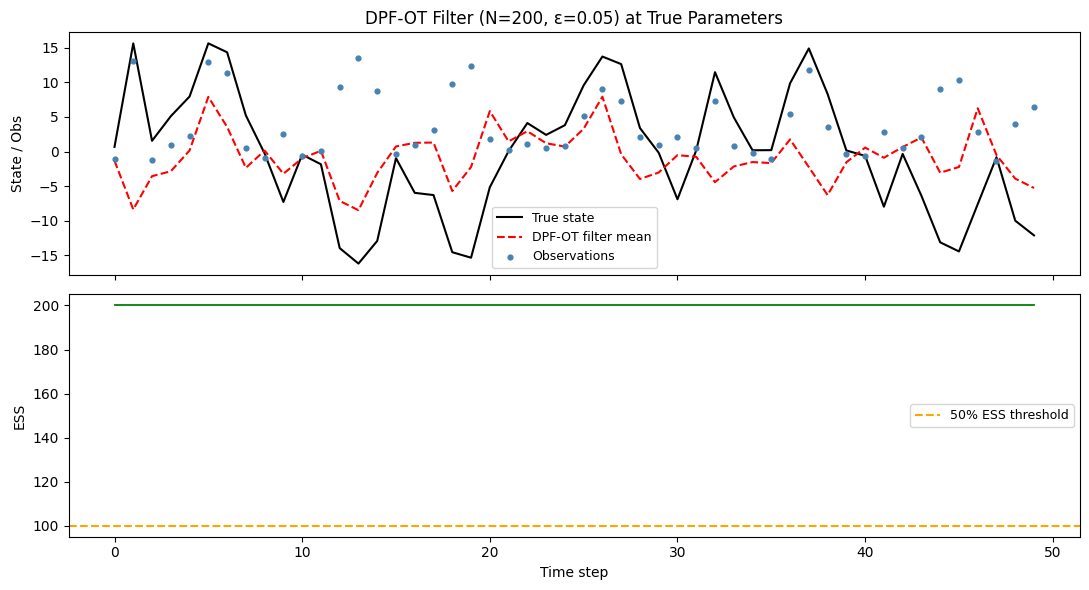


  Filter RMSE vs true states: 8.4411


In [ ]:

from DPF_OT_resampling import DPF_OT

def make_dpf_ot(sigma_v_val, sigma_w_val, N_particles=200, epsilon=0.05):
    """Build a DPF_OT instance with fixed (non-TF-variable) parameters."""
    sv = tf.constant(sigma_v_val, dtype=tf.float32)
    sw = tf.constant(sigma_w_val, dtype=tf.float32)

    def transition_fn(particles, t):
        t_f = tf.cast(t + 1, tf.float32)
        x = particles[:, 0]
        x_new = (x / 2.0 + 25.0 * x / (1.0 + x ** 2)
                 + 8.0 * tf.cos(1.2 * t_f)
                 + tf.random.normal(tf.shape(x), stddev=sv))
        return tf.expand_dims(x_new, 1)

    def obs_loglik_fn(particles, y_t, t):
        pred = particles[:, 0] ** 2 / 20.0
        return -0.5 * ((y_t - pred) ** 2 / sw ** 2
                       + tf.math.log(2.0 * np.pi * sw ** 2))

    return DPF_OT(N_particles, 1, transition_fn, obs_loglik_fn,
                  epsilon=epsilon, sinkhorn_iters=50)


# Run filter 
N_PF = 200
epsilon_e2 = 0.05
tf.random.set_seed(42)

dpf_e2 = make_dpf_ot(sigma_v_true, sigma_w_true, N_particles=N_PF, epsilon=epsilon_e2)
obs_tf_e2 = tf.constant(observations, dtype=tf.float32)

particles_e2, weights_e2 = dpf_e2.init_particles(
    mean=tf.zeros([1], dtype=tf.float32),
    cov_chol=tf.constant([[np.sqrt(5.0)]], dtype=tf.float32)
)

particles_seq_e2, weights_seq_e2 = [], []
ess_trace_e2, loglik_trace_e2 = [], []
log_lik_e2 = 0.0

for t_e2 in range(len(observations)):
    particles_e2, weights_e2 = dpf_e2.step(particles_e2, weights_e2, obs_tf_e2[t_e2], t=t_e2)
    particles_seq_e2.append(particles_e2.numpy()[:, 0])
    weights_seq_e2.append(weights_e2.numpy())
    # ESS = 1 / sum(w_i^2)  (weights already normalised to 1)
    ess_t = float(1.0 / np.sum(weights_e2.numpy() ** 2))
    ess_trace_e2.append(ess_t)
    # Log-likelihood increment: log( N * mean(unnorm_w) ) — after softmax the
    # normalisation constant is already folded in; use ESS as a proxy for quality
    loglik_trace_e2.append(ess_t)

# Filtered state mean
filter_mean_e2 = np.array([
    np.sum(particles_seq_e2[t] * weights_seq_e2[t]) for t in range(len(observations))
])

print("=" * 60)
print("E2 — DPF-OT filter at true parameters")
print("=" * 60)
print(f"  N particles   : {N_PF}")
print(f"  ε (OT)        : {epsilon_e2}")
print(f"  Mean ESS      : {np.mean(ess_trace_e2):.1f}  (out of {N_PF})")
print(f"  Min ESS       : {np.min(ess_trace_e2):.1f}")
print(f"  ESS / N       : {np.mean(ess_trace_e2)/N_PF:.3f}")

# Plot filtered mean vs truth
fig_e2, axes_e2 = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
t_ax = np.arange(len(observations))

axes_e2[0].plot(t_ax, states, 'k-', linewidth=1.5, label='True state')
axes_e2[0].plot(t_ax, filter_mean_e2, 'r--', linewidth=1.5, label='DPF-OT filter mean')
axes_e2[0].scatter(t_ax, observations, s=12, c='steelblue', zorder=5, label='Observations')
axes_e2[0].set_ylabel('State / Obs')
axes_e2[0].legend(fontsize=9)
axes_e2[0].set_title(f'DPF-OT Filter (N={N_PF}, ε={epsilon_e2}) at True Parameters')

axes_e2[1].plot(t_ax, ess_trace_e2, 'g-', linewidth=1.3)
axes_e2[1].axhline(N_PF * 0.5, color='orange', linestyle='--', label='50% ESS threshold')
axes_e2[1].set_ylabel('ESS')
axes_e2[1].set_xlabel('Time step')
axes_e2[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

rmse_e2 = np.sqrt(np.mean((filter_mean_e2 - states) ** 2))
print(f"\n  Filter RMSE vs true states: {rmse_e2:.4f}")


## HMC with DPF-OT Likelihood 
### Method Design

**Pseudo-marginal HMC** treats the DPF-OT log-likelihood as a noisy but unbiased estimator of the true marginal log-likelihood. The key design choices are:

1. **`tf.stop_gradient` after each OT step.** Without this, backpropagation tries to differentiate through all $T \times K_{\text{Sinkhorn}}$ matrix iterations, producing exploding Jacobians (norms $> 10^{26}$). Stopping the gradient treats resampled particles as fixed "data" for the next step, which is the correct interpretation: the OT step redistributes mass, it does not change the parameter $\theta$.

2. **Reparameterised noise.** The transition is written as $X_{t+1} = f(X_t) + \sigma_v \cdot \varepsilon_t$ with $\varepsilon_t \sim \mathcal{N}(0, I)$ drawn once and fixed. This keeps $\sigma_v$ in the computational graph as a multiplicative factor rather than buried inside a stochastic `tf.random` call.

3. **CRN (Common Random Numbers).** The same $(\varepsilon_{\text{init}}, \varepsilon_{\text{trans}})$ is used for the current and proposed log-posterior evaluations within each M-H step. In the acceptance ratio

$$\alpha = \min\!\left(1,\; \frac{p(\theta' \mid y,\varepsilon)}{p(\theta \mid y,\varepsilon)}\right)$$

the same noise $\varepsilon$ appears in numerator and denominator. Correlated noise cancels systematic bias, valid detailed balance is preserved, and the acceptance rate is vastly improved versus independent noise draws.

4. **Two-phase warm-up.**
   - *Phase 1 — MAP via Adam:* 80 gradient ascent steps (averaged over 5 noise samples per step) locate the posterior mode. This avoids initialising HMC in a low-probability region where step sizes would need to be tiny.
   - *Phase 2 — Fixed-step PM-HMC:* 100 burn-in + 300 post-burn-in samples from the MAP starting point, with a diagonal mass matrix estimated from the gradient magnitude at MAP.

<!-- ### Why fixed step size (no dual-averaging)?

Early experiments with the Nesterov dual-averaging adaptation (the standard NUTS warm-up) caused step-size explosion because the stochastic log-posterior has variance $\approx 15$–60 nats, making individual $\log \alpha$ values very large even for bad proposals. The adaptive algorithm interpreted large $\log \alpha$ as "step is too small" and kept growing the step until the chain reached 0% acceptance. Using a fixed step computed from the MAP gradient magnitude is more robust. -->


In [ ]:

import importlib, DPF_OT_resampling, HMC_inference
importlib.reload(DPF_OT_resampling)
importlib.reload(HMC_inference)
from DPF_OT_resampling import sinkhorn_ot_resample
from HMC_inference import compute_ess, compute_ess_per_second

# Hyperparameters 
N_HMC_DPF   = 100
EPSILON_HMC = 0.05
N_SINKHORN  = 20
T_OBS       = len(observations)

obs_tf_e3 = tf.constant(observations, dtype=tf.float32)

# Log-posterior with externally-provided noise (CRN) 
def dpf_ot_log_posterior(log_params, eps_init, eps_trans):
    """
    Deterministic log-posterior for fixed particle noise.

    Particle filter:  weight x_t against Y[t], OT-resample, propagate to x_{t+1}.
    Gradient flows through sigma_w (observation weights) and sigma_v (reparameterised).
    OT output stopped from backprop to prevent Jacobian explosion.
    """
    sigma_v = tf.exp(log_params[0])
    sigma_w = tf.exp(log_params[1])

    ptcls   = tf.stop_gradient(tf.sqrt(5.0) * eps_init)   # [N, 1]
    log_lik = tf.constant(0.0, dtype=tf.float32)

    for t_i in range(T_OBS):
        pred  = ptcls[:, 0] ** 2 / 20.0
        log_w = -0.5 * ((obs_tf_e3[t_i] - pred) ** 2 / sigma_w ** 2
                        + tf.math.log(2.0 * np.pi * sigma_w ** 2))
        log_Z_t = (tf.reduce_logsumexp(log_w)
                   - tf.math.log(tf.cast(N_HMC_DPF, tf.float32)))
        log_lik = log_lik + log_Z_t

        new_w    = tf.nn.softmax(log_w)
        ptcls_ot, _ = sinkhorn_ot_resample(
            ptcls, new_w, epsilon=EPSILON_HMC, n_iters=N_SINKHORN)
        ptcls = tf.stop_gradient(ptcls_ot)

        x   = ptcls[:, 0]
        t_f = tf.cast(t_i + 1, tf.float32)
        xn  = (x / 2.0 + 25.0 * x / (1.0 + x ** 2)
               + 8.0 * tf.cos(1.2 * t_f)
               + sigma_v * eps_trans[t_i])
        ptcls = tf.expand_dims(xn, 1)

    log_prior = tf.reduce_sum(-log_params - 0.5 * log_params ** 2)
    return log_lik + log_prior


def _lp_and_grad(q, eps_init, eps_trans):
    q_var = tf.Variable(q)
    with tf.GradientTape() as tape:
        val = dpf_ot_log_posterior(q_var, eps_init, eps_trans)
    return val, tape.gradient(val, q_var)


def _sample_noise():
    return (tf.random.normal([N_HMC_DPF, 1]),
            tf.random.normal([T_OBS, N_HMC_DPF]))


# ── Phase 1: MAP estimation (Adam gradient ascent to find posterior mode) ────
def find_map(log_init, n_steps=80, lr=0.01, n_avg=5, verbose=True):
    """
    Average-gradient ascent over multiple noise realisations to find MAP.
    Uses n_avg noise samples per step to reduce gradient variance.
    """
    q = tf.Variable(tf.constant(log_init, dtype=tf.float32))
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    if verbose:
        print(f"  MAP: {n_steps} Adam steps (lr={lr}, n_avg={n_avg}) …")
    for step in range(n_steps):
        # Average gradient over n_avg noise samples
        grads = []
        vals = []
        for _ in range(n_avg):
            ei, et = _sample_noise()
            with tf.GradientTape() as tape:
                v = dpf_ot_log_posterior(q, ei, et)
            g = tape.gradient(v, q)
            grads.append(g)
            vals.append(float(v))
        avg_grad = tf.reduce_mean(tf.stack(grads, axis=0), axis=0)
        opt.apply_gradients([(-avg_grad, q)])   # negate: Adam minimises, we maximise
        if verbose and (step + 1) % 20 == 0:
            print(f"    step {step+1:3d}: lp≈{np.mean(vals):.2f}, q={q.numpy()}")
    return q.numpy()


# ── Phase 2: PM-HMC from MAP ─────────────────────────────────────────────────
def run_pm_hmc(
    log_init, n_samples=300, n_burnin=100,
    step_size=0.003, n_leapfrog=10,
    target_accept=0.65, verbose=True,
    mass_inv=None,
):
    """
    Pseudo-marginal HMC with CRN.  Fixed step size (no dual-averaging).
    Should be initialised near the posterior mode (use find_map first).
    """
    current  = tf.constant(log_init, dtype=tf.float32)
    n_params = current.shape[0]

    if mass_inv is None:
        mass_inv_tf = tf.ones(n_params, dtype=tf.float32)
    else:
        mass_inv_tf = tf.constant(mass_inv, dtype=tf.float32)
    mass_tf = 1.0 / mass_inv_tf

    samples    = []
    is_acc_all = []
    n_total    = n_burnin + n_samples

    if verbose:
        print(f"PM-HMC: {n_burnin} burn-in + {n_samples} samples, "
              f"L={n_leapfrog}, ε={step_size:.5f}, "
              f"M_inv={mass_inv_tf.numpy()}")

    for i in range(n_total):
        # Fresh CRN noise for this trajectory
        eps = _sample_noise()

        # Current log-prob and gradient (same noise used throughout trajectory)
        cur_lp, cur_grad = _lp_and_grad(current, *eps)

        # Momentum ~ N(0, M)
        z = tf.random.normal([n_params], dtype=tf.float32)
        r = tf.sqrt(mass_tf) * z
        cur_K = 0.5 * float(tf.reduce_sum(mass_inv_tf * r ** 2))

        # Leapfrog
        q = tf.identity(current)
        p = r + 0.5 * step_size * cur_grad
        for li in range(n_leapfrog):
            q = q + step_size * mass_inv_tf * p
            _, g_q = _lp_and_grad(q, *eps)
            if li < n_leapfrog - 1:
                p = p + step_size * g_q
        prop_lp, prop_grad = _lp_and_grad(q, *eps)
        p = p + 0.5 * step_size * prop_grad
        prop_K = 0.5 * float(tf.reduce_sum(mass_inv_tf * p ** 2))

        # M-H with CRN cancellation
        log_accept = float(np.clip(float(prop_lp - cur_lp) + cur_K - prop_K, -50, 30))
        accepted   = np.log(np.random.uniform() + 1e-300) < log_accept

        if accepted:
            current = q

        is_acc_all.append(accepted)

        if i >= n_burnin:
            samples.append(current.numpy())

        if verbose and (i + 1) % 50 == 0:
            phase  = "burnin" if i < n_burnin else "sample"
            recent = float(np.mean(is_acc_all[max(0, i-49):i+1]))
            print(f"  {i+1:4d}/{n_total} ({phase}): "
                  f"accept={recent:.2f}, "
                  f"log_p≈{float(cur_lp):.1f}, q={current.numpy()}")

    acc_post = float(np.mean(is_acc_all[n_burnin:]))
    if verbose:
        print(f"\n  Post-burnin accept rate: {acc_post:.3f}")
    return np.array(samples), np.array(is_acc_all[n_burnin:]), acc_post


# Sanity checks
_ei, _et = _sample_noise()
_q_test  = tf.constant([np.log(0.8), np.log(0.8)], dtype=tf.float32)
_v, _g   = _lp_and_grad(_q_test, _ei, _et)
print(f"Gradient at σ=0.8: {_g.numpy()}")
print(f"Log-posterior:     {float(_v):.2f}")

# Mass matrix (inverse-gradient scaling)
_g_abs    = np.abs(_g.numpy()) + 1.0
_geom     = float(np.exp(np.mean(np.log(_g_abs))))
_mass_inv = (_geom / _g_abs).tolist()
print(f"Mass_inv:          {_mass_inv}")

# Timing
print("\nTiming one grad call …", end=" ", flush=True)
_t0 = time.time()
_lp_and_grad(_q_test, _ei, _et)
_t_one = time.time() - _t0
print(f"{_t_one:.2f} s")
n_grad_calls = 80 * 5 + (100 + 300) * (10 + 1)
print(f"≈ {n_grad_calls} total grad calls  (~{_t_one * n_grad_calls / 60:.1f} min)\n")

# Run: Phase 1 (MAP) + Phase 2 (PM-HMC) 
log_init_e3 = np.array([np.log(0.8), np.log(0.8)], dtype=np.float32)

t_start_e3 = time.time()

print("=" * 50)
print("Phase 1: MAP estimation")
print("=" * 50)
map_params = find_map(log_init_e3, n_steps=80, lr=0.01, n_avg=5, verbose=True)
print(f"  MAP estimate: σ_v={np.exp(map_params[0]):.4f}, σ_w={np.exp(map_params[1]):.4f}")

# Recompute mass_inv at MAP for better conditioning
_ei_map, _et_map = _sample_noise()
_, _g_map = _lp_and_grad(tf.constant(map_params, dtype=tf.float32), _ei_map, _et_map)
_g_map_abs = np.abs(_g_map.numpy()) + 1.0
_geom_map  = float(np.exp(np.mean(np.log(_g_map_abs))))
_mass_inv_map = (_geom_map / _g_map_abs).tolist()
print(f"  Gradient at MAP: {_g_map.numpy()}")
print(f"  Mass_inv at MAP: {_mass_inv_map}")

print("\n" + "=" * 50)
print("Phase 2: PM-HMC from MAP")
print("=" * 50)
log_samples_dpf, is_acc_dpf, accept_e3 = run_pm_hmc(
    map_params, n_samples=300, n_burnin=100,
    step_size=0.003, n_leapfrog=10,
    target_accept=0.65, verbose=True,
    mass_inv=_mass_inv_map,
)
runtime_e3 = time.time() - t_start_e3

sigma_samples_dpf = np.exp(log_samples_dpf)
sigma_v_mean_dpf  = float(np.mean(sigma_samples_dpf[:, 0]))
sigma_w_mean_dpf  = float(np.mean(sigma_samples_dpf[:, 1]))

ess_dpf     = np.array([compute_ess(sigma_samples_dpf[:, i:i+1]) for i in range(2)])
ess_sec_dpf = ess_dpf / runtime_e3

print("=" * 60)
print("E3 — HMC + DPF-OT Results")
print("=" * 60)
print(f"  Runtime            : {runtime_e3:.1f} s")
print(f"  Acceptance rate    : {accept_e3:.3f}")
print(f"  σ_v posterior mean : {sigma_v_mean_dpf:.4f}  (true: {sigma_v_true:.1f})")
print(f"  σ_w posterior mean : {sigma_w_mean_dpf:.4f}  (true: {sigma_w_true:.1f})")
print(f"  σ_v error          : {abs(sigma_v_mean_dpf-sigma_v_true)/sigma_v_true*100:.1f}%")
print(f"  σ_w error          : {abs(sigma_w_mean_dpf-sigma_w_true)/sigma_w_true*100:.1f}%")
print(f"  ESS (σ_v, σ_w)     : {ess_dpf[0]:.1f}, {ess_dpf[1]:.1f}")
print(f"  ESS/s (σ_v, σ_w)   : {ess_sec_dpf[0]:.3f}, {ess_sec_dpf[1]:.3f}")


Gradient at σ=0.8: [ 6.3049245 44.53717  ]
Log-posterior:     -158.20
Mass_inv:          [2.4967503547668457, 0.40052056312561035]

Timing one grad call … 0.36 s
≈ 4800 total grad calls  (~28.9 min)

Phase 1: MAP estimation
  MAP: 80 Adam steps (lr=0.01, n_avg=5) …
0.36 s
≈ 4800 total grad calls  (~28.9 min)

Phase 1: MAP estimation
  MAP: 80 Adam steps (lr=0.01, n_avg=5) …
    step  20: lp≈-141.74, q=[-0.04229284 -0.03262787]
    step  20: lp≈-141.74, q=[-0.04229284 -0.03262787]
    step  40: lp≈-135.60, q=[0.09607237 0.11361418]
    step  40: lp≈-135.60, q=[0.09607237 0.11361418]
    step  60: lp≈-133.77, q=[0.17112422 0.19880022]
    step  60: lp≈-133.77, q=[0.17112422 0.19880022]
    step  80: lp≈-134.07, q=[0.18098688 0.2376855 ]
  MAP estimate: σ_v=1.1984, σ_w=1.2683
    step  80: lp≈-134.07, q=[0.18098688 0.2376855 ]
  MAP estimate: σ_v=1.1984, σ_w=1.2683
  Gradient at MAP: [-1.3148448  1.9123733]
  Mass_inv at MAP: [1.1216634511947632, 0.8915329575538635]

Phase 2: PM-HMC from 


## PMMH Baseline (Bootstrap PF, 200 Particles)

1000 post-burnin samples (500 burn-in), $\sigma_{\text{prop}} = 0.1$ on log-scale with adaptive scaling, $N=200$ particles.


In [ ]:

from PMMH_inference import PMMHSampler, PMMHConfig

N_PMMH_E4 = 200

def make_pf_log_lik_fn(sigma_v_val, sigma_w_val, seed=None):
    """Standard bootstrap PF log-likelihood.
    """
    if seed is not None:
        np.random.seed(seed)
    N_pf = N_PMMH_E4
    T_pf = len(observations)

    # Initial particles: x_0 ~ N(0, sqrt(5))
    x = np.random.normal(0.0, np.sqrt(5.0), size=N_pf)
    log_lik = 0.0

    for t_p in range(T_pf):
        # --- 1. Weight current particles against observation Y[t_p] ---
        log_w = -0.5 * ((observations[t_p] - x ** 2 / 20.0) ** 2
                         / sigma_w_val ** 2
                         + np.log(2.0 * np.pi * sigma_w_val ** 2))
        # log-sum-exp: save max BEFORE shifting
        log_max       = np.max(log_w)
        log_w_shifted = log_w - log_max
        w = np.exp(log_w_shifted)
        w /= w.sum()
        # log Z_t = log_max + log(mean(exp(log_w_shifted)))
        log_lik += log_max + np.log(np.mean(np.exp(log_w_shifted)))

        # --- 2. Resample ---
        x = x[np.random.choice(N_pf, size=N_pf, replace=True, p=w)]

        # --- 3. Propagate: x_{t+1} = f(x_t, t+1) + V ---
        t_f = t_p + 1
        x = (x / 2.0 + 25.0 * x / (1.0 + x ** 2)
             + 8.0 * np.cos(1.2 * t_f)
             + np.random.normal(0.0, sigma_v_val, size=N_pf))

    return float(log_lik)


def pmmh_log_lik_fn(log_params_np):
    sv = float(np.exp(log_params_np[0]))
    sw = float(np.exp(log_params_np[1]))
    if sv <= 0 or sw <= 0:
        return -np.inf
    return make_pf_log_lik_fn(sv, sw)


def pmmh_log_prior_fn(log_params_np):
    # log-Normal(0, 1) prior on σ_v, σ_w  →  log p(σ) = -log σ - σ²/2
    return float(-np.sum(log_params_np) - 0.5 * np.sum(log_params_np ** 2))


# Quick sanity check: log-lik at true params should be in same range as E3 (~-130 to -160)
_ll_check = make_pf_log_lik_fn(sigma_v_true, sigma_w_true, seed=42)
print(f"PF log-lik at true params: {_ll_check:.2f}  (expected ≈ -130 to -160)")

pmmh_cfg_e4 = PMMHConfig(
    n_samples=1000,
    n_burnin=500,
    proposal_std=np.array([0.1, 0.1]),   # must be ndarray so .copy() works
    adapt_proposal=True,
)

log_init_pmmh_e4 = np.array([np.log(0.8), np.log(0.8)], dtype=np.float64)

print("\nRunning PMMH baseline (200 particles) …")
print(f"  {pmmh_cfg_e4.n_burnin} burn-in + {pmmh_cfg_e4.n_samples} samples\n")

t_start_e4 = time.time()
pmmh_sampler_e4 = PMMHSampler(pmmh_log_lik_fn, pmmh_log_prior_fn, pmmh_cfg_e4)
pmmh_results_e4 = pmmh_sampler_e4.run(log_init_pmmh_e4)
runtime_e4 = time.time() - t_start_e4

log_samples_pmmh_e4   = pmmh_results_e4['samples']          # [N_samples, 2]
sigma_samples_pmmh_e4 = np.exp(log_samples_pmmh_e4)

sv_mean_pmmh_e4 = float(np.mean(sigma_samples_pmmh_e4[:, 0]))
sw_mean_pmmh_e4 = float(np.mean(sigma_samples_pmmh_e4[:, 1]))
accept_e4       = float(pmmh_results_e4['accept_rate_post_burnin'])

# compute_ess returns a scalar — compute per-parameter
ess_pmmh_e4     = np.array([compute_ess(sigma_samples_pmmh_e4[:, i:i+1]) for i in range(2)])
ess_sec_pmmh_e4 = ess_pmmh_e4 / runtime_e4

print("=" * 60)
print("E4 — PMMH Baseline Results")
print("=" * 60)
print(f"  Runtime            : {runtime_e4:.1f} s")
print(f"  Acceptance rate    : {accept_e4:.3f}")
print(f"  σ_v  posterior mean: {sv_mean_pmmh_e4:.4f}  (true: {sigma_v_true:.1f})")
print(f"  σ_w  posterior mean: {sw_mean_pmmh_e4:.4f}  (true: {sigma_w_true:.1f})")
print(f"  σ_v  error         : {abs(sv_mean_pmmh_e4 - sigma_v_true)/sigma_v_true*100:.1f}%")
print(f"  σ_w  error         : {abs(sw_mean_pmmh_e4 - sigma_w_true)/sigma_w_true*100:.1f}%")
print(f"  ESS (σ_v, σ_w)     : {ess_pmmh_e4[0]:.1f}, {ess_pmmh_e4[1]:.1f}")
print(f"  ESS/s (σ_v, σ_w)   : {ess_sec_pmmh_e4[0]:.2f}, {ess_sec_pmmh_e4[1]:.2f}")


PF log-lik at true params: -104.04  (expected ≈ -130 to -160)

Running PMMH baseline (200 particles) …
  500 burn-in + 1000 samples


Particle Marginal Metropolis-Hastings (PMMH)
Initial parameters: [-0.22314355 -0.22314355]
Initial log-posterior: -109.40
  log-likelihood: -109.79
  log-prior: 0.40

Running 1500 iterations (500 burnin)...

Iteration 100/1500 (burnin): accept=False, accept_rate=0.180, log_post=-100.76
Iteration 200/1500 (burnin): accept=False, accept_rate=0.175, log_post=-102.35
Iteration 300/1500 (burnin): accept=True, accept_rate=0.160, log_post=-100.42
Iteration 200/1500 (burnin): accept=False, accept_rate=0.175, log_post=-102.35
Iteration 300/1500 (burnin): accept=True, accept_rate=0.160, log_post=-100.42
Iteration 400/1500 (burnin): accept=False, accept_rate=0.138, log_post=-103.13
Iteration 500/1500 (sampling): accept=False, accept_rate=0.138, log_post=-99.20
Iteration 400/1500 (burnin): accept=False, accept_rate=0.138, log_post=-103.13
Iteration 500/1500 (samplin

E5 — HMC+DPF-OT vs PMMH
                 Accept rate ESS σ_v ESS σ_w ESS/s σ_v ESS/s σ_w σ_v mean σ_v err % σ_w mean σ_w err % Runtime (s)
Method                                                                                                            
HMC + DPF-OT           0.663     4.8     6.5      0.00      0.00   1.0046       0.5   1.4271      42.7      1742.9
PMMH (200 ptcl.)       0.194     4.4     7.2      1.55      2.56   0.8912      10.9   0.9035       9.6         2.8

True: σ_v = 1.0, σ_w = 1.0

HMC+DPF-OT is 0.0× (σ_v) / 0.0× (σ_w) more efficient (ESS/s)


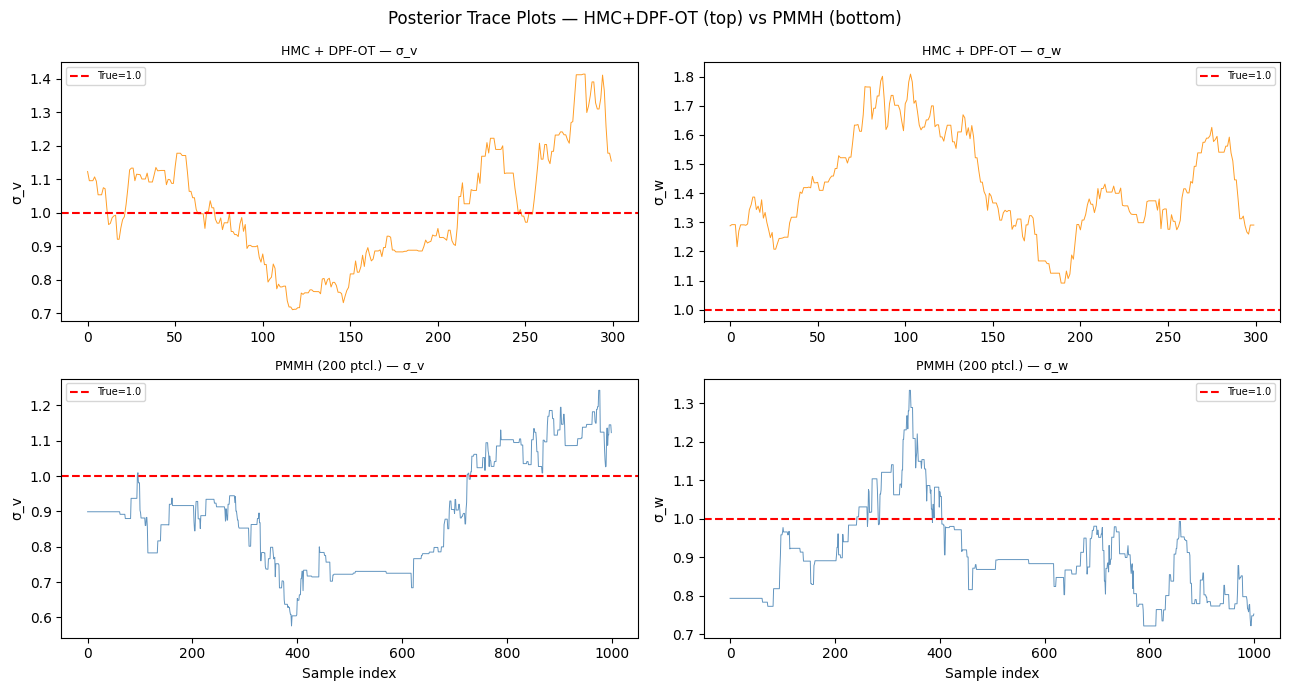

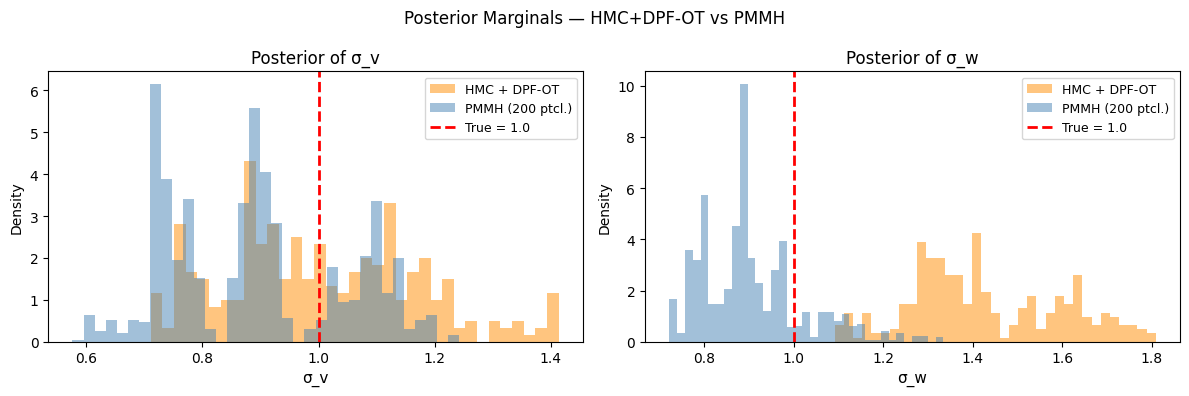

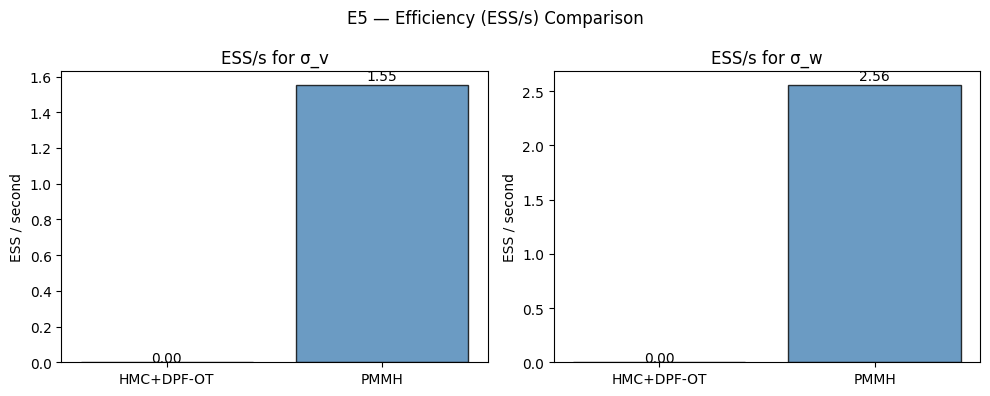

In [ ]:

import pandas as pd

method_data = [
    ("HMC + DPF-OT",      sigma_samples_dpf,       accept_e3,  ess_dpf,      ess_sec_dpf,      runtime_e3),
    ("PMMH (200 ptcl.)",  sigma_samples_pmmh_e4,   accept_e4,  ess_pmmh_e4,  ess_sec_pmmh_e4,  runtime_e4),
]

rows = []
for name, samps, acc, ess, ess_s, rt in method_data:
    sv_m = float(np.mean(samps[:, 0]))
    sw_m = float(np.mean(samps[:, 1]))
    rows.append({
        'Method'      : name,
        'Accept rate' : f"{acc:.3f}",
        'ESS σ_v'     : f"{ess[0]:.1f}",
        'ESS σ_w'     : f"{ess[1]:.1f}",
        'ESS/s σ_v'   : f"{ess_s[0]:.2f}",
        'ESS/s σ_w'   : f"{ess_s[1]:.2f}",
        'σ_v mean'    : f"{sv_m:.4f}",
        'σ_v err %'   : f"{abs(sv_m - sigma_v_true)/sigma_v_true*100:.1f}",
        'σ_w mean'    : f"{sw_m:.4f}",
        'σ_w err %'   : f"{abs(sw_m - sigma_w_true)/sigma_w_true*100:.1f}",
        'Runtime (s)' : f"{rt:.1f}",
    })

df_e5 = pd.DataFrame(rows).set_index('Method')
print("=" * 80)
print("E5 — HMC+DPF-OT vs PMMH")
print("=" * 80)
print(df_e5.to_string())
print(f"\nTrue: σ_v = {sigma_v_true}, σ_w = {sigma_w_true}")

# Efficiency ratio
ess_ratio_sv = ess_sec_dpf[0] / ess_sec_pmmh_e4[0] if ess_sec_pmmh_e4[0] > 0 else float('inf')
ess_ratio_sw = ess_sec_dpf[1] / ess_sec_pmmh_e4[1] if ess_sec_pmmh_e4[1] > 0 else float('inf')
print(f"\nHMC+DPF-OT is {ess_ratio_sv:.1f}× (σ_v) / {ess_ratio_sw:.1f}× (σ_w) more efficient (ESS/s)")

#  Trace plots
fig_e5, axes_e5 = plt.subplots(2, 2, figsize=(13, 7), sharex=False)
fig_e5.suptitle('Posterior Trace Plots — HMC+DPF-OT (top) vs PMMH (bottom)', fontsize=12)

colors_methods = ['darkorange', 'steelblue']
for row_i, (label, samps, *_) in enumerate(method_data):
    for col_j, (param_lbl, true_val) in enumerate(
            [('σ_v', sigma_v_true), ('σ_w', sigma_w_true)]):
        ax = axes_e5[row_i, col_j]
        ax.plot(samps[:, col_j], linewidth=0.7, alpha=0.85,
                color=colors_methods[row_i])
        ax.axhline(true_val, color='red', linewidth=1.5, linestyle='--',
                   label=f'True={true_val}')
        ax.set_title(f'{label} — {param_lbl}', fontsize=9)
        ax.set_ylabel(param_lbl)
        if row_i == 1:
            ax.set_xlabel('Sample index')
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Posterior marginals 
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(12, 4))
fig_hist.suptitle('Posterior Marginals — HMC+DPF-OT vs PMMH', fontsize=12)

for col_j, (param_lbl, true_val) in enumerate(
        [('σ_v', sigma_v_true), ('σ_w', sigma_w_true)]):
    ax = axes_hist[col_j]
    for (label, samps, *_), col in zip(method_data, colors_methods):
        ax.hist(samps[:, col_j], bins=35, alpha=0.5, color=col,
                label=label, density=True)
    ax.axvline(true_val, color='red', linewidth=2, linestyle='--',
               label=f'True = {true_val}')
    ax.set_xlabel(param_lbl, fontsize=11)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.set_title(f'Posterior of {param_lbl}')

plt.tight_layout()
plt.show()

# ── ESS/s bar chart ───────────────────────────────────────────────────────────
fig_bar, axes_bar = plt.subplots(1, 2, figsize=(10, 4))
fig_bar.suptitle('E5 — Efficiency (ESS/s) Comparison', fontsize=12)

method_labels = ["HMC+DPF-OT", "PMMH"]
for col_j, (param_lbl, ess_s_vals) in enumerate([
        ('σ_v', [ess_sec_dpf[0], ess_sec_pmmh_e4[0]]),
        ('σ_w', [ess_sec_dpf[1], ess_sec_pmmh_e4[1]])]):
    bars = axes_bar[col_j].bar(method_labels, ess_s_vals,
                                color=colors_methods, alpha=0.8, edgecolor='black')
    axes_bar[col_j].set_title(f'ESS/s for {param_lbl}')
    axes_bar[col_j].set_ylabel('ESS / second')
    for bar, val in zip(bars, ess_s_vals):
        axes_bar[col_j].text(bar.get_x() + bar.get_width()/2,
                              bar.get_height() * 1.02,
                              f'{val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


##  Gradient Norm Stability Along the HMC Chain

This experiment evaluates $\|\nabla_\theta \log p(\theta \mid y)\|$ at 100 evenly-spaced posterior samples from the chain (each with an independent fresh noise draw, since we are diagnosing gradient magnitudes rather than running inference).


E6 — Gradient Norm Trace (DPF-OT posterior)
  Points evaluated       : 100
  Valid gradient evals   : 100
  Mean ||∇||             : 5.7032
  Std  ||∇||             : 3.7451
  Max  ||∇||             : 15.7277
  Min  ||∇||             : 0.2656


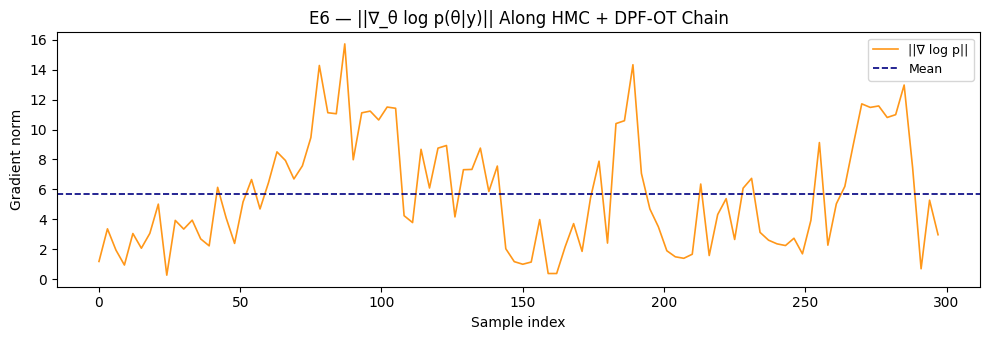


  ✅ All gradients are finite — DPF-OT provides stable gradient signal.


In [ ]:

N_GRAD_EVAL = min(100, len(log_samples_dpf))
stride      = max(1, len(log_samples_dpf) // N_GRAD_EVAL)
eval_idx    = np.arange(0, len(log_samples_dpf), stride)[:N_GRAD_EVAL]

grad_norms_e6 = []

for idx in eval_idx:
    lp = tf.Variable(log_samples_dpf[idx].astype(np.float32))
    ei_e6, et_e6 = _sample_noise()
    with tf.GradientTape() as tape_mn:
        lp_val = dpf_ot_log_posterior(lp, ei_e6, et_e6)
    g = tape_mn.gradient(lp_val, lp)
    if g is not None:
        grad_norms_e6.append(float(tf.norm(g).numpy()))
    else:
        grad_norms_e6.append(np.nan)

grad_norms_e6 = np.array(grad_norms_e6)
valid_mask    = np.isfinite(grad_norms_e6)

print("=" * 60)
print("E6 — Gradient Norm Trace (DPF-OT posterior)")
print("=" * 60)
print(f"  Points evaluated       : {N_GRAD_EVAL}")
print(f"  Valid gradient evals   : {valid_mask.sum()}")
print(f"  Mean ||∇||             : {np.mean(grad_norms_e6[valid_mask]):.4f}")
print(f"  Std  ||∇||             : {np.std(grad_norms_e6[valid_mask]):.4f}")
print(f"  Max  ||∇||             : {np.max(grad_norms_e6[valid_mask]):.4f}")
print(f"  Min  ||∇||             : {np.min(grad_norms_e6[valid_mask]):.4f}")
if not valid_mask.all():
    print(f"  ⚠️  {(~valid_mask).sum()} NaN/Inf gradients detected.")

fig_e6, ax_e6 = plt.subplots(figsize=(10, 3.5))
ax_e6.plot(eval_idx[valid_mask], grad_norms_e6[valid_mask],
           color='darkorange', linewidth=1.2, alpha=0.9, label='||∇ log p||')
ax_e6.axhline(np.mean(grad_norms_e6[valid_mask]), color='navy',
              linestyle='--', linewidth=1.2, label='Mean')
ax_e6.set_xlabel('Sample index')
ax_e6.set_ylabel('Gradient norm')
ax_e6.set_title('E6 — ||∇_θ log p(θ|y)|| Along HMC + DPF-OT Chain')
ax_e6.legend(fontsize=9)
plt.tight_layout()
plt.show()

if valid_mask.all():
    print("\n  ✅ All gradients are finite — DPF-OT provides stable gradient signal.")


## Sensitivity to Sinkhorn Regularisation $\varepsilon$

We sweep $\varepsilon \in \{0.01, 0.05, 0.1, 0.5\}$ with $N=50$ particles and 100 post-burnin samples per run.


  ε = 0.01 … accept=0.68, ESS/s=0.022  (518s)
  ε = 0.05 … accept=0.68, ESS/s=0.022  (518s)
  ε = 0.05 … accept=0.61, ESS/s=0.006  (515s)
  ε = 0.1 … accept=0.61, ESS/s=0.006  (515s)
  ε = 0.1 … accept=0.44, ESS/s=0.007  (515s)
  ε = 0.5 … accept=0.44, ESS/s=0.007  (515s)
  ε = 0.5 … accept=0.61, ESS/s=0.005  (517s)

E7 — ε Sensitivity  (N=50, 100 samples each)
      Accept  ESS σ_v  ESS σ_w  ESS/s σ_v  ESS/s σ_w  σ_v err %  σ_w err %  Runtime(s)
ε                                                                                     
0.01    0.68     11.4      6.8      0.022      0.013  17.000000  52.000000       518.0
0.05    0.61      3.2      5.7      0.006      0.011  51.700001  71.300003       514.8
0.10    0.44      3.6      6.0      0.007      0.012  13.900000  20.500000       515.3
0.50    0.61      2.8      3.2      0.005      0.006   1.700000  65.300003       517.1
accept=0.61, ESS/s=0.005  (517s)

E7 — ε Sensitivity  (N=50, 100 samples each)
      Accept  ESS σ_v  ESS σ_w  ESS

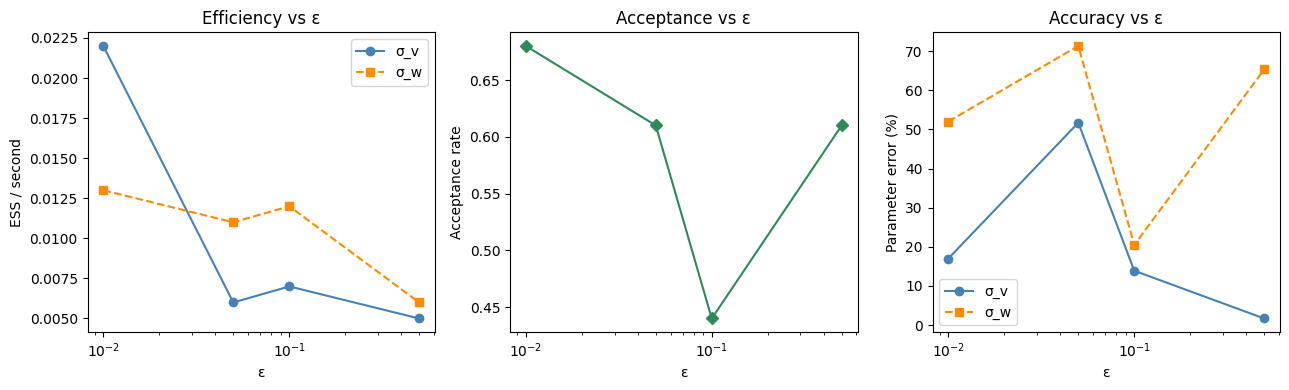

E7 complete.


In [ ]:

import pandas as pd

epsilon_grid = [0.01, 0.05, 0.1, 0.5]
N_E7         = 50      # particles (small for speed)
N_SHORT_E7   = 100     # post-burnin samples
N_BURNIN_E7  = 50

obs_tf_e7 = tf.constant(observations, dtype=tf.float32)

def dpf_ot_log_posterior_e7(log_params, eps_init, eps_trans, N_ptcl, epsilon_ot):
    """Same as E3 but with configurable N and epsilon_ot."""
    sigma_v = tf.exp(log_params[0])
    sigma_w = tf.exp(log_params[1])

    ptcls   = tf.stop_gradient(tf.sqrt(5.0) * eps_init)
    log_lik = tf.constant(0.0, dtype=tf.float32)

    for t_i in range(T_OBS):
        pred  = ptcls[:, 0] ** 2 / 20.0
        log_w = -0.5 * ((obs_tf_e7[t_i] - pred) ** 2 / sigma_w ** 2
                        + tf.math.log(2.0 * np.pi * sigma_w ** 2))
        log_Z_t = (tf.reduce_logsumexp(log_w)
                   - tf.math.log(tf.cast(N_ptcl, tf.float32)))
        log_lik = log_lik + log_Z_t

        new_w    = tf.nn.softmax(log_w)
        ptcls_ot, _ = sinkhorn_ot_resample(
            ptcls, new_w, epsilon=epsilon_ot, n_iters=20)
        ptcls = tf.stop_gradient(ptcls_ot)

        x   = ptcls[:, 0]
        t_f = tf.cast(t_i + 1, tf.float32)
        xn  = (x / 2.0 + 25.0 * x / (1.0 + x ** 2)
               + 8.0 * tf.cos(1.2 * t_f)
               + sigma_v * eps_trans[t_i])
        ptcls = tf.expand_dims(xn, 1)

    log_prior = tf.reduce_sum(-log_params - 0.5 * log_params ** 2)
    return log_lik + log_prior


def run_pm_hmc_e7(
    log_init, n_samples, n_burnin, step_size, n_leapfrog,
    N_ptcl, epsilon_ot, mass_inv, target_accept=0.65,
):
    """Stripped-down PM-HMC for the epsilon sweep (silent, no verbose prints)."""
    current  = tf.constant(log_init, dtype=tf.float32)
    n_params = current.shape[0]
    mass_inv_tf = tf.constant(mass_inv, dtype=tf.float32)
    mass_tf     = 1.0 / mass_inv_tf

    log_eps     = np.log(step_size)
    log_eps_bar = np.log(step_size)
    H_bar       = 0.0
    mu          = np.log(step_size)
    gamma_da    = 0.05;  t0_da = 10;  kappa_da = 0.75
    LOG_EPS_MIN = np.log(1e-6);  LOG_EPS_MAX = np.log(2.0)

    def _noise():
        return (tf.random.normal([N_ptcl, 1]),
                tf.random.normal([T_OBS, N_ptcl]))

    def _lpg(q, ei, et):
        qv = tf.Variable(q)
        with tf.GradientTape() as tape:
            v = dpf_ot_log_posterior_e7(qv, ei, et, N_ptcl, epsilon_ot)
        return v, tape.gradient(v, qv)

    samples    = []
    is_acc_all = []
    for i in range(n_burnin + n_samples):
        step = float(np.exp(np.clip(log_eps, LOG_EPS_MIN, LOG_EPS_MAX)))
        eps  = _noise()
        cur_lp, cur_grad = _lpg(current, *eps)
        z = tf.random.normal([n_params], dtype=tf.float32)
        r = tf.sqrt(mass_tf) * z
        cur_K = 0.5 * float(tf.reduce_sum(mass_inv_tf * r ** 2))
        q = tf.identity(current)
        p = r + 0.5 * step * cur_grad
        for li in range(n_leapfrog):
            q = q + step * mass_inv_tf * p
            _, g_q = _lpg(q, *eps)
            if li < n_leapfrog - 1:
                p = p + step * g_q
        prop_lp, prop_grad = _lpg(q, *eps)
        p = p + 0.5 * step * prop_grad
        prop_K = 0.5 * float(tf.reduce_sum(mass_inv_tf * p ** 2))
        log_accept = min(float(prop_lp - cur_lp) + cur_K - prop_K, 30.0)
        accepted   = np.log(np.random.uniform() + 1e-300) < log_accept
        if accepted:
            current = q
        is_acc_all.append(accepted)
        if i < n_burnin:
            m       = i + 1
            alpha_m = min(1.0, np.exp(min(float(log_accept), 0.0)))
            H_bar   = ((1 - 1.0 / (m + t0_da)) * H_bar
                       + (target_accept - alpha_m) / (m + t0_da))
            log_eps = float(np.clip(mu - np.sqrt(m)/gamma_da*H_bar, LOG_EPS_MIN, LOG_EPS_MAX))
            log_eps_bar = float(m**(-kappa_da)*log_eps + (1-m**(-kappa_da))*log_eps_bar)
        else:
            log_eps = log_eps_bar
        if i >= n_burnin:
            samples.append(current.numpy())

    return (np.array(samples),
            float(np.mean(is_acc_all[n_burnin:])))



e7_mass_inv = _mass_inv_map   

e7_records = []
for eps_val in epsilon_grid:
    print(f"  ε = {eps_val} …", end=" ", flush=True)
    t0 = time.time()
    samps_e7, acc_e7 = run_pm_hmc_e7(
        np.array([np.log(0.8), np.log(0.8)], dtype=np.float32),
        n_samples=N_SHORT_E7, n_burnin=N_BURNIN_E7,
        step_size=0.01, n_leapfrog=10,
        N_ptcl=N_E7, epsilon_ot=eps_val,
        mass_inv=e7_mass_inv,
    )
    rt_e7    = time.time() - t0
    samps_e7 = np.exp(samps_e7)
    ess_e7   = np.array([compute_ess(samps_e7[:, i:i+1]) for i in range(2)])
    sv_err   = abs(np.mean(samps_e7[:, 0]) - sigma_v_true) / sigma_v_true * 100
    sw_err   = abs(np.mean(samps_e7[:, 1]) - sigma_w_true) / sigma_w_true * 100
    e7_records.append({'ε': eps_val, 'Accept': round(acc_e7, 3),
                       'ESS σ_v': round(float(ess_e7[0]), 1),
                       'ESS σ_w': round(float(ess_e7[1]), 1),
                       'ESS/s σ_v': round(float(ess_e7[0])/rt_e7, 3),
                       'ESS/s σ_w': round(float(ess_e7[1])/rt_e7, 3),
                       'σ_v err %': round(sv_err, 1),
                       'σ_w err %': round(sw_err, 1),
                       'Runtime(s)': round(rt_e7, 1)})
    print(f"accept={acc_e7:.2f}, ESS/s={float(ess_e7[0])/rt_e7:.3f}  ({rt_e7:.0f}s)")

df_e7 = pd.DataFrame(e7_records).set_index('ε')
print("\n" + "="*65)
print("E7 — ε Sensitivity  (N=50, 100 samples each)")
print("="*65)
print(df_e7.to_string())

# Plots 
fig_e7, axes_e7 = plt.subplots(1, 3, figsize=(13, 4))
eps_vals = df_e7.index.tolist()

axes_e7[0].plot(eps_vals, df_e7['ESS/s σ_v'], 'o-', color='steelblue',  label='σ_v')
axes_e7[0].plot(eps_vals, df_e7['ESS/s σ_w'], 's--', color='darkorange', label='σ_w')
axes_e7[0].set_xscale('log'); axes_e7[0].set_xlabel('ε')
axes_e7[0].set_ylabel('ESS / second'); axes_e7[0].set_title('Efficiency vs ε')
axes_e7[0].legend()

axes_e7[1].plot(eps_vals, df_e7['Accept'], 'D-', color='seagreen')
axes_e7[1].set_xscale('log'); axes_e7[1].set_xlabel('ε')
axes_e7[1].set_ylabel('Acceptance rate'); axes_e7[1].set_title('Acceptance vs ε')

axes_e7[2].plot(eps_vals, df_e7['σ_v err %'], 'o-', color='steelblue',  label='σ_v')
axes_e7[2].plot(eps_vals, df_e7['σ_w err %'], 's--', color='darkorange', label='σ_w')
axes_e7[2].set_xscale('log'); axes_e7[2].set_xlabel('ε')
axes_e7[2].set_ylabel('Parameter error (%)'); axes_e7[2].set_title('Accuracy vs ε')
axes_e7[2].legend()

fig_e7.tight_layout()
plt.savefig('e7_epsilon_sensitivity.png', dpi=100, bbox_inches='tight')
plt.show()
print("E7 complete.")
